In [5]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
data_root = Path('/astrum/home/hpchzy/code/data/')
date_base = '20260509'

hosts = ['c920bn3', 'camd9554n2', 'cgnr6760pn2']
# 兼容后续仍按单主机写法的单元
hostname = hosts[0]

kernel = "jacobi2d5p"
# kernel = "tl_f90_cg_calc_w"

output = 'output_sampOpt_filtOpt'

freq_dict = {'camd9554n2': 3.1, 'cgnr6760pn2': 2.2, 'c920bn3': 2.9}


# Filt data

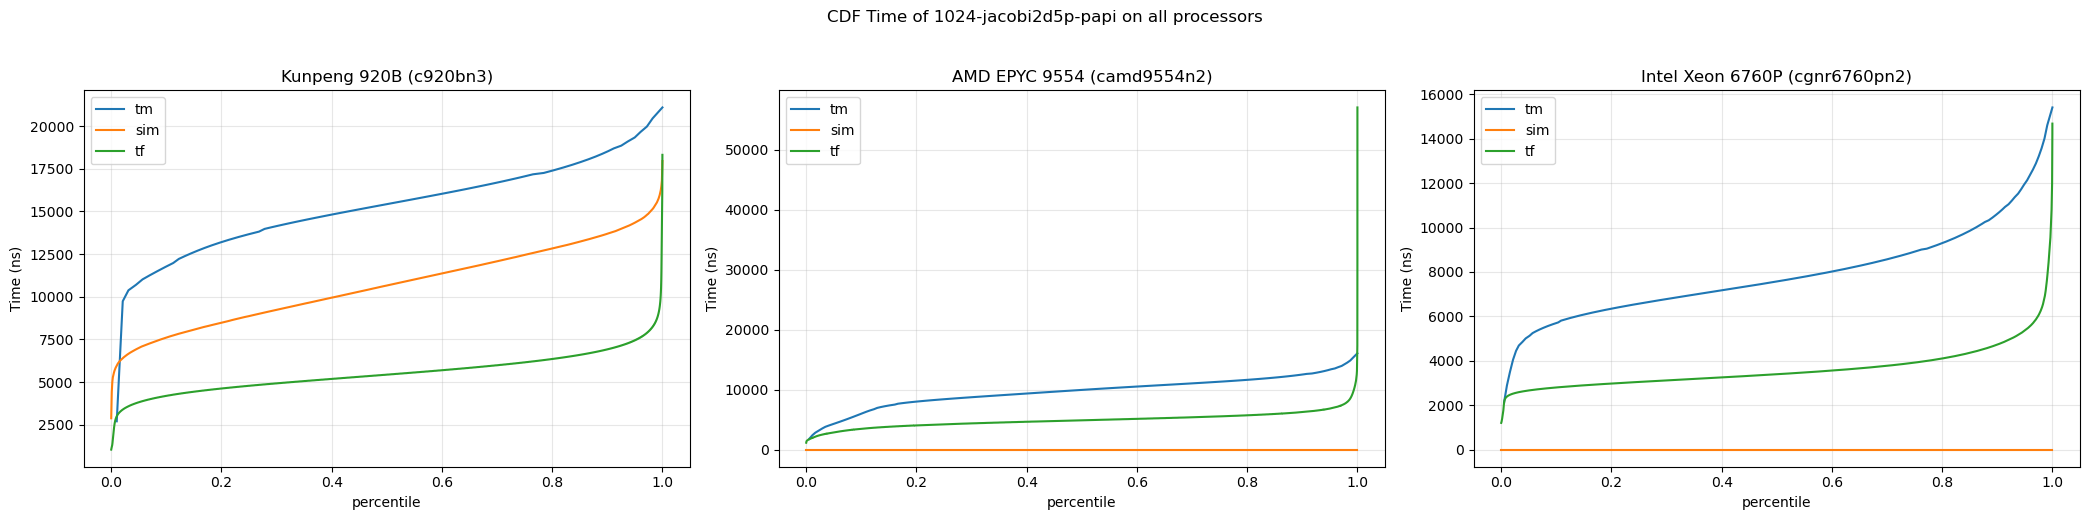

In [7]:
iarr = 1024
timer = 'papi'

host_name_map = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}

fig, axes = plt.subplots(1, len(hosts), figsize=(7 * len(hosts), 5), sharey=False)
if len(hosts) == 1:
    axes = [axes]

for ax, host in zip(axes, hosts):
    data_path = data_root / f'{date_base}/{host}/{output}'
    filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{host}_filt'

    tm_path = filt_folder_path / 'tm_hist.csv'
    sim_path = filt_folder_path / 'sim_cdf.csv'
    tf_path = filt_folder_path / 'tf.csv'

    if not (tm_path.exists() and sim_path.exists() and tf_path.exists()):
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{host_name_map.get(host, host)} ({host})")
        ax.set_xlabel('percentile')
        ax.set_ylabel('Time (ns)')
        ax.grid(True, alpha=0.3)
        continue

    tm_hist_df = pd.read_csv(tm_path, header=None)
    tm_hist_df.columns = ['ns', 'pr']
    tm_hist_df['ns'] = pd.to_numeric(tm_hist_df['ns'], errors='coerce')
    tm_hist_df['pr'] = pd.to_numeric(tm_hist_df['pr'], errors='coerce')
    tm_hist_df = (
        tm_hist_df.dropna(subset=['ns', 'pr'])
        .loc[lambda d: d['pr'] > 0.0]
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )
    tm_hist_df['cdf'] = tm_hist_df['pr'].cumsum()

    sim_hist_df = pd.read_csv(sim_path, header=None)
    sim_hist_df.columns = ['idx', 'sim_cdf', 'wasserstein', '%wasserstein']
    sim_hist_df['idx'] = pd.to_numeric(sim_hist_df['idx'], errors='coerce')
    max_idx = sim_hist_df['idx'].max()
    if pd.isna(max_idx) or max_idx == 0:
        sim_hist_df['cdf'] = np.nan
    else:
        sim_hist_df['cdf'] = sim_hist_df['idx'] / max_idx

    tf_df = pd.read_csv(tf_path, header=None)
    tf_df.columns = ['ns']
    tf_df['ns'] = pd.to_numeric(tf_df['ns'], errors='coerce')
    tf_hist_df = (
        tf_df.dropna(subset=['ns'])
        .groupby('ns', as_index=False)
        .size()
        .rename(columns={'size': 'cnt'})
        .sort_values('ns', kind='stable')
        .reset_index(drop=True)
    )
    tf_hist_df['pr'] = tf_hist_df['cnt'] / tf_hist_df['cnt'].sum()
    tf_hist_df['cdf'] = tf_hist_df['pr'].cumsum()
    quantile_val = tf_hist_df['ns'].quantile(0.9)
    tf_hist_df = tf_hist_df[tf_hist_df['ns'] < quantile_val]

    sns.lineplot(data=tm_hist_df, x='cdf', y='ns', label='tm', ax=ax)
    sns.lineplot(data=sim_hist_df, x='cdf', y='sim_cdf', label='sim', ax=ax)
    sns.lineplot(data=tf_hist_df, x='cdf', y='ns', label='tf', ax=ax)
    ax.set_xlabel('percentile')
    ax.set_ylabel('Time (ns)')
    ax.set_title(f"{host_name_map.get(host, host)} ({host})")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f'CDF Time of {iarr}-{kernel}-{timer} on all processors', y=1.03)
plt.tight_layout()
plt.show()

# Raw data

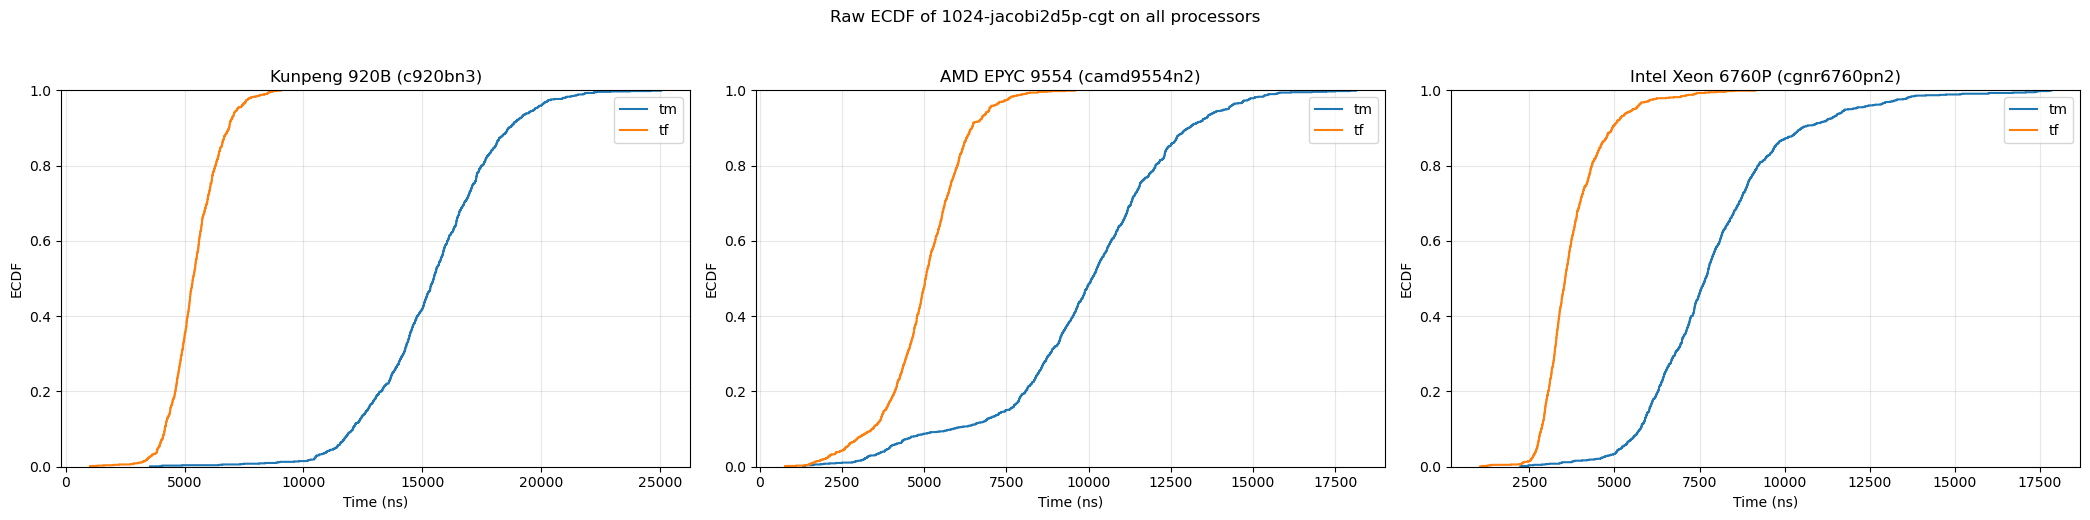

In [10]:
# pd.options.plotting.backend = 'plotly'

iarr = 1024
timer = 'cgt'

host_name_map = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}

fig, axes = plt.subplots(1, len(hosts), figsize=(7 * len(hosts), 5), sharey=False)
if len(hosts) == 1:
    axes = [axes]

for ax, host in zip(axes, hosts):
    data_path = data_root / f'{date_base}/{host}/{output}'
    filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{host}_filt'

    met_path = filt_folder_path / 'met.csv'
    tf_path = filt_folder_path / 'tf.csv'

    if not (met_path.exists() and tf_path.exists()):
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{host_name_map.get(host, host)} ({host})")
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('ECDF')
        ax.grid(True, alpha=0.3)
        continue

    tm_df = pd.read_csv(met_path, header=None)
    tm_df.columns = ['ns']
    tm_df['ns'] = pd.to_numeric(tm_df['ns'], errors='coerce')
    tm_df = tm_df.dropna(subset=['ns'])
    if not tm_df.empty:
        quantile_val = tm_df['ns'].quantile(0.995)
        tm_df = tm_df[tm_df['ns'] <= quantile_val]

    tf_df = pd.read_csv(tf_path, header=None)
    tf_df.columns = ['ns']
    tf_df['ns'] = pd.to_numeric(tf_df['ns'], errors='coerce')
    tf_df = tf_df.dropna(subset=['ns'])
    if not tf_df.empty:
        quantile_val = tf_df['ns'].quantile(0.995)
        tf_df = tf_df[tf_df['ns'] <= quantile_val]

    if tm_df.empty or tf_df.empty:
        ax.text(0.5, 0.5, 'empty data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{host_name_map.get(host, host)} ({host})")
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('ECDF')
        ax.grid(True, alpha=0.3)
        continue

    tm_df_sampled = tm_df.sample(n=min(1000, len(tm_df)), random_state=42)
    tf_df_sampled = tf_df.sample(n=min(1000, len(tf_df)), random_state=42)

    sns.ecdfplot(data=tm_df_sampled, x='ns', ax=ax, label='tm')
    sns.ecdfplot(data=tf_df_sampled, x='ns', ax=ax, label='tf')

    ax.set_title(f"{host_name_map.get(host, host)} ({host})")
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('ECDF')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f'Raw ECDF of {iarr}-{kernel}-{timer} on all processors', y=1.03)
plt.tight_layout()
plt.show()

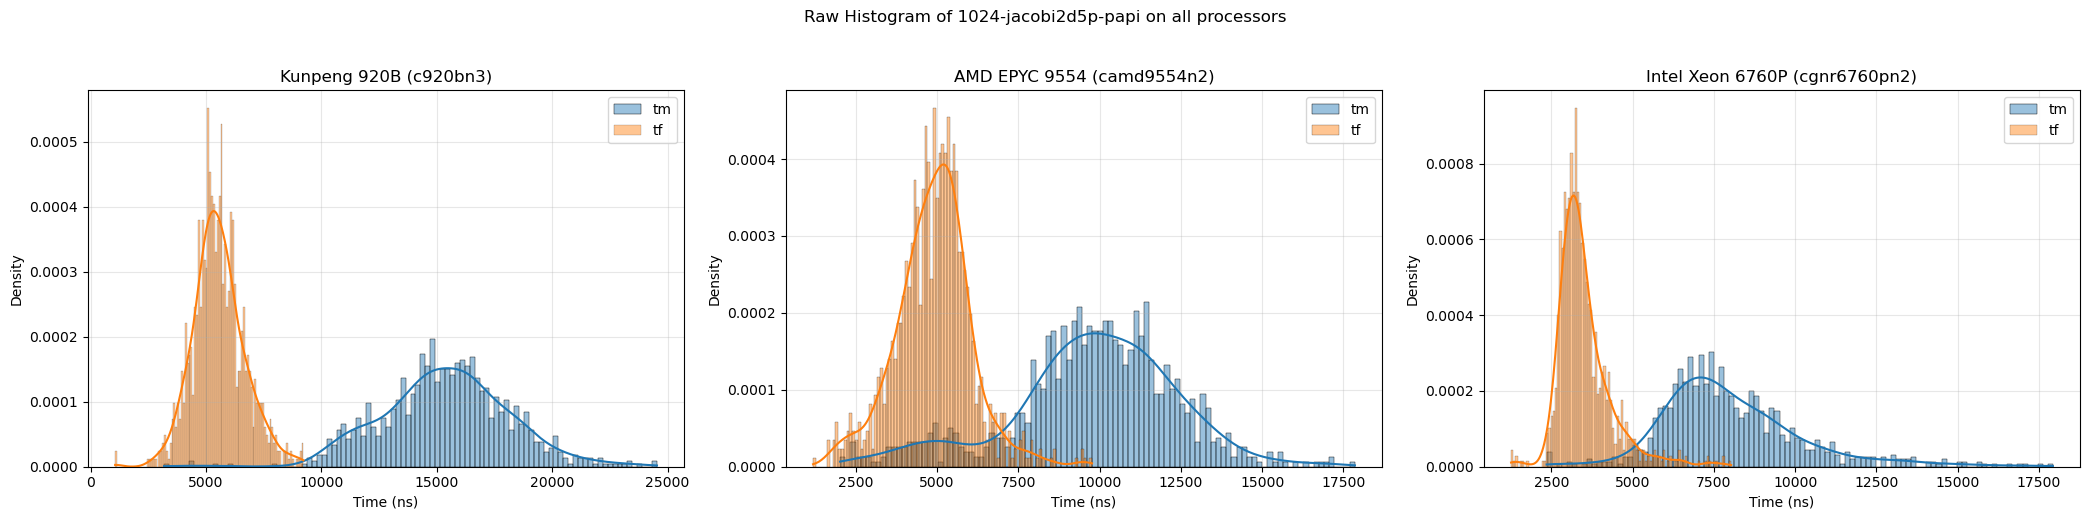

In [11]:
# pd.options.plotting.backend = 'plotly'

iarr = 1024
timer = 'papi'

host_name_map = {
    'c920bn3': 'Kunpeng 920B',
    'camd9554n2': 'AMD EPYC 9554',
    'cgnr6760pn2': 'Intel Xeon 6760P',
}

fig, axes = plt.subplots(1, len(hosts), figsize=(7 * len(hosts), 5), sharey=False)
if len(hosts) == 1:
    axes = [axes]

for ax, host in zip(axes, hosts):
    data_path = data_root / f'{date_base}/{host}/{output}'
    filt_folder_path = data_path / f'{kernel}{iarr}n100t_{timer}_{host}_filt'

    met_path = filt_folder_path / 'met.csv'
    tf_path = filt_folder_path / 'tf.csv'

    if not (met_path.exists() and tf_path.exists()):
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{host_name_map.get(host, host)} ({host})")
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        continue

    tm_df = pd.read_csv(met_path, header=None)
    tm_df.columns = ['ns']
    tm_df['ns'] = pd.to_numeric(tm_df['ns'], errors='coerce')
    tm_df = tm_df.dropna(subset=['ns'])

    tf_df = pd.read_csv(tf_path, header=None)
    tf_df.columns = ['ns']
    tf_df['ns'] = pd.to_numeric(tf_df['ns'], errors='coerce')
    tf_df = tf_df.dropna(subset=['ns'])

    if not tm_df.empty:
        q_tm = tm_df['ns'].quantile(0.995)
        tm_df = tm_df[tm_df['ns'] <= q_tm]
    if not tf_df.empty:
        q_tf = tf_df['ns'].quantile(0.995)
        tf_df = tf_df[tf_df['ns'] <= q_tf]

    if tm_df.empty or tf_df.empty:
        ax.text(0.5, 0.5, 'empty data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{host_name_map.get(host, host)} ({host})")
        ax.set_xlabel('Time (ns)')
        ax.set_ylabel('Density')
        ax.grid(True, alpha=0.3)
        continue

    tm_df_sampled = tm_df.sample(n=min(1000, len(tm_df)), random_state=42)
    tf_df_sampled = tf_df.sample(n=min(1000, len(tf_df)), random_state=42)

    sns.histplot(data=tm_df_sampled, x='ns', bins=100, kde=True, ax=ax, label='tm', stat='density', alpha=0.45)
    sns.histplot(data=tf_df_sampled, x='ns', bins=100, kde=True, ax=ax, label='tf', stat='density', alpha=0.45)

    ax.set_title(f"{host_name_map.get(host, host)} ({host})")
    ax.set_xlabel('Time (ns)')
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle(f'Raw Histogram of {iarr}-{kernel}-{timer} on all processors', y=1.03)
plt.tight_layout()
plt.show()

<Axes: ylabel='Density'>

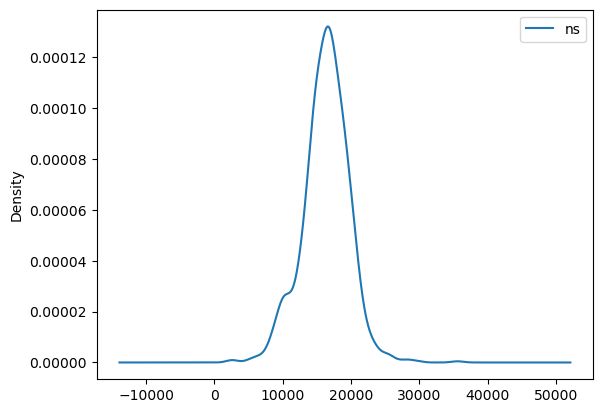

In [ ]:
tm_df_sampled.plot.kde()